# [실습] 시간당 수요 차수 결정 — AIC 비교표 6조합

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## 0. 오늘 쓸 데이터와 첫날에 정해진 설정 3개

<div style="background:#FFFFFF;color:#000000;padding:40px;border-radius:12px;border:1px solid #E6E6E6;border-left:4px solid #051C2C">
<div style="font-size:0.9em;color:#656565">시계열 예측 · 둘째 날</div>
<h1 style="color:#000000;margin:10px 0">168시간 배차표 — 모형의 차수 2개 결정하기</h1>
<div style="font-size:1.05em;color:#656565">첫날에 보정한 계열로 다음 주 168시간을 채울 모형의 차수를 정하고, 그 근거를 AIC 표 한 장으로 남기는 순서입니다</div>
</div>

## 오늘 할 일

아침에 배차팀장이 다음과 같이 요청했습니다. **"다음 주 트럭 배차표를 금요일까지 결정해야 합니다. 요일별이 아니라 시간대별로, 다음 7일 168시간의 수요를 숫자로 주세요."**

그래서 오늘의 질문은 하나입니다. **그 168시간을 무엇으로 채울 것인가.** 먼저 하루 합계 계열로 대신할 수 있는지 확인하고, 시간 단위 모형의 차수를 결정합니다.

오늘 사용할 설정 3개는 첫날의 진단에서 이미 결정되었습니다. 계절 주기 m = 24, 계절차분 D = 1, **1차 차분(first differencing)** 횟수 d = 0 입니다. 오늘 결정할 것은 비계절 차수 p 와 q 2개입니다. 1차 차분 횟수 d 는 후보 전체에 같은 값으로 통일하고, 계절차분은 첫날에 정한 대로 D = 1 입니다.

미션은 2개이고, 그중 차수를 정하는 미션 2 가 오늘 반드시 남겨야 할 결과입니다. 미션 1 은 시간이 남을 때 합니다. 맨 끝의 「오늘의 정리」는 미션 2 까지만 마친 상태에서도 읽을 수 있습니다. 코드 작성은 대부분 AI 튜터에게 맡기고, 우리는 **시킬 일을 결정하고 받은 결과를 확인하는 역할**을 담당합니다.

<img src="https://otexts.com/fpp3/fpp_files/figure-html/auscafecombPI-1.png" width="640" height="320"/>
<p align="center"><em>▲ 호주 월별 외식 지출액에 대해 만든 예측 — 검은 선이 실측, 파란 선이 예측이고 짙은 영역이 80% · 옅은 영역이 95% 예측구간이다. (출처: Hyndman &amp; Athanasopoulos, Forecasting: Principles and Practice 3rd ed., otexts.com/fpp3)</em></p>

## 오늘의 데이터

**Seoul Bike Sharing Demand** 는 UCI 머신러닝 저장소가 공개한 서울 공유자전거의 시간당 대여 기록입니다. 한 행이 한 시간이고, 2017년 12월 1일 0시부터 2018년 11월 30일 23시까지 8,760행 × 14열입니다. 빠진 시각은 없습니다.

기록 안에는 시스템이 정지해 대여가 한 대도 기록되지 않은 시간이 295개 있습니다. 운영 여부 열 `functioning` 이 `"No"` 인 시각이고, 이하 **휴무 295시간**이라 부릅니다. 그 0 은 수요가 없었다는 뜻이 아니라 관측이 없다는 뜻입니다.

그래서 「준비 셀」은 원본 시간 계열 `count` 를 그대로 두고, 휴무 295시간을 1주일 전 같은 시각 값으로 채운 **보정 수요** `demand` 를 새 열로 따로 만듭니다. 첫날에 정한 대로 **탐색과 검정은 원본 시간 계열, 모형 학습과 예측과 평가는 보정 수요**입니다. 첫날에 만든 파일을 이어받지는 않고, 미션마다 「준비 셀」이 이 zip 을 직접 열어 사용할 변수를 처음부터 만듭니다.

한 시간에 한 값씩 있는 계열은 산문에서 **시간당 수요**로 부릅니다. 코드와 채점 라벨에서는 원본 시간 계열 `count` 입니다.

<img src="https://commons.wikimedia.org/wiki/Special:FilePath/Bicycle-sharing%20station%20at%20Hangang%20bikeway%202.jpg?width=1600" width="640" height="467"/>
<p align="center"><em>▲ 거치대에 정렬된 공유자전거 — 오늘 만들 168시간 표가 결정하는 것은 「몇 대를 몇 시에 채워 두는가」다 (출처: Wikimedia Commons, Bicycle-sharing station at Hangang bikeway)</em></p>

## 이 노트북을 쓰는 법

**미션마다 코드 셀이 2개입니다.** 앞의 것은 사용할 변수를 만드는 셀이라 그대로 실행하고, 뒤의 것은 `PROMPT` 를 내 말로 적어 AI 튜터에게 시키는 셀입니다. 앞을 **「준비 셀」**, 뒤를 **「PROMPT 셀」** 이라 부릅니다. AI 가 작성한 코드는 `# --- 여기부터 AI 코드 ---` 표시선 아래에 들어옵니다.

**출력 이름 규칙** — 「만들 것」에 굵게 적힌 이름을 글자 그대로 사용해 「이름 = 값 단위」 한 행으로 출력합니다. 변수 이름은 자유이며, 채점 기준은 이 출력 행과 그림입니다.

| 무엇 | 어떻게 |
|---|---|
| 실행 환경 | CPU 로 충분합니다. ▶ 실행은 Google Colab 연결 안내를 따르고, AI 튜터는 상단 「Claude 도우미」를 설치한 뒤에 사용합니다. **채점은 Colab 이 연결되면 자동으로 준비됩니다. 코드 패널 위쪽에 「채점 준비됨」이 표시된 뒤에 미션을 시작하고, 미션 셀을 실행했는데 채점 결과가 출력되지 않으면 그 「채점 준비됨」을 누르세요.** 노트북을 내려받아 Colab 이나 내 컴퓨터에서 열었다면 맨 위의 접힌 `[채점]` 셀을 한 번 ▶ 실행한 뒤 시작합니다(코드는 접혀 있어도 실행됩니다). |
| 먼저 실행할 셀 | 맨 위 설치·폰트 셀(한 번이면 됩니다). 설치 뒤 numpy 관련 오류가 발생하면 런타임을 다시 시작하고 이 셀부터 다시 실행합니다 |
| 채점 | 실행하는 순간 실행 결과에 채점 결과가 출력됩니다. 채점 기준을 모두 충족하면 완성본 풀이가 열리고, 충족하지 못하면 어긋난 항목과 AI 튜터에 보낼 질문이 나옵니다 |
| 막혔을 때 | 같은 말을 두 번 그대로 다시 쓰지 말고 `PROMPT` 에 빠진 조건을 하나 추가합니다. 그래도 안 되면 앞 대화를 이어서 쓰지 말고 요구를 한 덩어리로 다시 적어 새 메시지로 보냅니다 |

In [1]:
# 실습 준비 - 패키지 설치
!pip install -q "numpy>=1.26" "pandas>=2.0" "matplotlib>=3.7" "statsmodels==0.14.6" "pmdarima==2.1.1"

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings; warnings.filterwarnings("ignore")

# 한글 폰트 — Colab 이면 나눔고딕을 설치한 뒤 그 ttf 를 폰트 목록에 **직접** 등록한다.
#  설치는 디스크에 파일만 만든다. 이미 떠 있는 폰트 목록은 그 사실을 모르므로 addfont 로
#  넣어 줘야 이름이 보인다(넣지 않으면 DejaVu Sans 로 밀려 한글이 전부 □ 로 나온다).
import glob, shutil, subprocess
if shutil.which("apt-get"):
    subprocess.run(["apt-get", "-y", "-qq", "install", "fonts-nanum"], check=False)
for _p in glob.glob("/usr/share/fonts/truetype/nanum/Nanum*.ttf"):   # 설치 여부와 무관하게 한 번
    try: fm.fontManager.addfont(_p)
    except Exception: pass
try: fm._get_font.cache_clear()
except Exception: pass
installed = {f.name for f in fm.fontManager.ttflist}
FONT = next((n for n in ["Pretendard", "Apple SD Gothic Neo", "NanumGothic"] if n in installed), "DejaVu Sans")
plt.rcParams["font.family"] = FONT
plt.rcParams["axes.unicode_minus"] = FONT in {"Pretendard", "DejaVu Sans"}   # 나머지 폰트에는 U+2212 가 없다
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}   # 그림마다 폭이 깎이지 않게
plt.rcParams["figure.dpi"] = plt.rcParams["savefig.dpi"] = 150       # 폭 FIG_W x 150dpi = 1500px 고정
plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 12,
                     "legend.fontsize": 11, "figure.titlesize": 17, "font.weight": "regular",
                     "text.color": "black", "axes.labelcolor": "black", "axes.titlecolor": "black",
                     "axes.edgecolor": "#757575", "xtick.color": "#757575", "ytick.color": "#757575",
                     "xtick.labelcolor": "black", "ytick.labelcolor": "black",
                     "axes.spines.top": False, "axes.spines.right": False, "axes.grid": False})

# 오늘 그림 전체가 함께 쓰는 색 — 0 기준선=남색, 관측=파랑, 강조=하늘색, 문맥=회색
COL = {"남색": "#051C2C", "파랑": "#2251FF", "하늘색": "#00A9F4",
       "회색": "#757575", "연회색": "#B3B3B3"}
FIG_W = 10.0     # 캔버스 폭은 오늘 그림 모두 이 값으로 고정하고 높이만 그림마다 조절한다


def datefmt(ax, fmt="%m-%d", n=5):
    """시간 축 눈금 개수와 표기를 잡아 날짜 라벨이 겹치지 않게 한다"""
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=n))
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))


def rmse(a, b):
    """두 계열의 평균 제곱근 오차 — ML 수업에서 쓰던 그 지표 그대로"""
    return float(np.sqrt(np.mean((np.asarray(a, dtype=float) - np.asarray(b, dtype=float)) ** 2)))


def mae(a, b):
    return float(np.mean(np.abs(np.asarray(a, dtype=float) - np.asarray(b, dtype=float))))

print("사용 폰트:", FONT)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 42.9 MB/s eta 0:00:00
사용 폰트: NanumGothic


## 1. 하루 합계 계열의 검토

시간이 모자라면 미션 2 만 합니다. 미션 1 은 시간이 남을 때 합니다.

### 미션 1 [선택] — 하루 합계 365일 계열로 168시간을 대신할 수 있는가

#### 할 일 — 미션 1 (25분)

1. 아래 「준비 셀」을 실행합니다. 이 셀은 고치지 않습니다.
2. 아래 만들 것대로 「PROMPT 셀」의 PROMPT 에 시킵니다.
3. 셀을 클릭한 채 AI 튜터에게 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶.
4. 실행 결과에 출력되는 채점 결과를 봅니다. ❌ 면 힌트대로 PROMPT 를 고쳐 3번부터 다시 합니다.

**이 미션의 질문** — 배차팀이 요청한 168시간을 하루 합계 365일 계열로 대신할 수 있을까요?

**쓸 수 있는 것** — 「준비 셀」이 만들어 둔 이름입니다.

| 이름 | 무엇 | 다룸 |
|---|---|---|
| `daily_c` | 일 수요 — 원본 시간 계열의 하루 합계 365일, 단위 대/일 | 고정 |
| `auto_arima` | 차수를 자동으로 고르는 함수 | 그대로 호출한다 |
| `df` · `df['count']` | 시간당 기록 표 전체와 원본 시간 계열, 단위 대 | 고정 |
| `acf` | 시차별 자기상관을 한 번에 반환하는 함수 | 그대로 호출한다 |

#### 만들 것

「PROMPT 셀」 한 곳에서 아래가 모두 출력되게 합니다. 굵은 이름은 글자 그대로 사용합니다. `daily_c` 에 `auto_arima` 를 한 번 적용하고, 1번과 2번은 그 결과에서 읽습니다.

1. **하루 합계 계열 1차 차분 횟수 d** — 단위 회 · 정수 · 탐색이 고른 비계절 차수 (p, d, q) 의 가운데 값
2. **하루 합계 계열 AIC** — 단위 없는 점수 · 소수점 아래 2자리 · 그 모형의 AIC
3. **그래프 한 장** — 가로축은 시차 1일부터 21일까지, 세로축은 자기상관인 막대 그래프
   - 대상 계열 : `daily_c` 에서 하루 전 값을 뺀 계열(1차 차분 1회)
   - 막대 : 시차 1 부터 21 까지 21개
   - 색 : 요일에 해당하는 시차 7 · 14 · 21 만 다른 색으로 강조합니다
   - 가로 점선 : 경계선 ±1.96/√T 를 가로축 전체에 걸쳐 위아래 하나씩 2개
   - 경계선 : 자기상관이 0 과 구별되는지 판단하는 기준선. T 는 그 계열의 자료 수
   - 가로축 이름 : 「시차 (일)」 · 세로축 이름 : 「자기상관」
4. **참고 행** — 채점하지 않는 한 행 · 탐색이 고른 차수와 계절 차수, 경계선, 시차 7 · 14 · 21 의 자기상관을 등호 없이 적습니다. 퀴즈 두 문항이 이 행을 봅니다

**조건** — 이번 탐색은 계절 차수를 고르지 않습니다. `seasonal=False` 는 계절 주기를 선언하지 않겠다는 뜻입니다. 그러면 탐색은 비계절 차수 p · d · q 만 고릅니다.

호출은 이웃한 차수만 이동하며 비교하는 **단계적 탐색(stepwise)** 으로 합니다. 후보를 빠짐없이 적합하는 전수 탐색은 지정하지 않습니다. 전수 탐색을 지정하면 AIC 가 달라져 기준 범위를 벗어납니다.

**출력 형식** — 값 2개를 「이름 = 값 단위」 형태로 **서로 다른 행에 한 행씩** `print` 합니다. 참고 행은 등호 없이 한 행 더 적습니다. 그래프는 한 장입니다.

**통과 기준** — 굵은 이름 2개가 각각 자기 행에 적혀 있고 그 값이 기준 범위에 들어야 합니다. 막대 21개와 경계선 2개와 가로축·세로축 이름까지 갖추면 통과입니다. 채점 화면은 이 경계선을 「가로선」이라 부릅니다.

<img src="https://otexts.com/fpp3/fpp_files/figure-html/beeracf-1.png" width="640" height="192"/>
<p align="center"><em>▲ 호주 분기별 맥주 생산량의 자기상관 — 한 주기가 4분기인 계열에서 시차 4 · 8 · 12 · 16 이 경계선 바깥으로 함께 커지고, 주기의 절반인 시차 2 · 6 · 10 · 14 는 음수 방향으로 경계선 바깥으로 벗어난다. 둘 다 같은 계절 구조다 (출처: Hyndman &amp; Athanasopoulos, Forecasting: Principles and Practice 3rd ed., otexts.com/fpp3)</em></p>

<img src="https://otexts.com/fpp3/fpp_files/figure-html/wnacfplus-1.png" width="640" height="192"/>
<p align="center"><em>▲ 자기상관이 없는 백색잡음 계열 3개의 자기상관 막대 — 왼쪽에서 오른쪽으로 자료 수가 늘면 경계선 사이가 좁아진다. 경계선은 1.96 을 자료 수의 제곱근으로 나눈 값이고, 막대가 그 안쪽에 있으면 자기상관이 0 이라고 본다 (출처: 같은 책)</em></p>

#### 프롬프트에 넣을 것(힌트)

- **고정할 이름** — `daily_c` · `auto_arima` 는 이미 있으므로 다시 만들지 말라고 적습니다.
- **탐색 조건** — 계절 차수를 고르지 않는다는 것(`seasonal=False`), 기준 점수가 AIC 라는 것, 단계적 탐색을 쓴다는 것.
- **출력** — 값 2개의 이름과 단위, 소수점 아래 몇 자리까지 출력할지, 두 값을 서로 다른 행에 둔다는 것. 참고 행에 넣을 값과 등호를 쓰지 않는다는 것.
- **그래프** — 어느 계열의 몇 번째 시차부터 그릴지 · 강조할 요일 시차 · 경계선 2개 · 가로축과 세로축 이름.

**막히면** — AI 튜터에게 「`auto_arima` 는 1차 차분 횟수 d 를 무엇으로 정하나요」 처럼 질문하세요.

#### 예상 적기

하나를 고르고, 그렇게 판단한 이유를 한 문장 적으세요. 하루 합계 계열은 365일 동안 여름에 오르고 겨울에 내려가는 움직임이 큽니다.

> **[예측] 하루 합계 365일 계열에 `auto_arima` 를 적용하면 1차 차분 횟수 d 가 몇으로 나올까요?**
>
> 1. 0 — 차분하지 않아도 평균 수준이 일정하다
> 2. 1 — 하루 전 값을 한 번 빼야 평균 수준이 일정해진다
> 3. 2 — 하루 전 값을 두 번 빼야 평균 수준이 일정해진다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

**읽는 법** — 실행해 두 값과 그림을 받은 뒤에 아래 「자세히」 를 펼칩니다. d 가 1 이면 하루 합계 계열은 차분 없이는 평균 수준이 일정하지 않다는 뜻입니다. AIC 는 이 365일 계열에서만 뜻이 있는 점수입니다. 미션 2 의 시간당 수요 AIC 와 나란히 놓지 않습니다.

<details class="lms-extra"><summary>자세히 — 받은 그림과 요일 차이를 읽는 순서</summary>

그림에서 가장 먼저 보이는 막대는 시차 1 의 −0.50 입니다. 하루 합계에서 하루 전 값을 빼면, 어제 튄 값이 오늘은 반대 부호로 한 번 더 나타나 음수가 됩니다. 시스템이 멈춰 합계가 0 인 12일이 이 막대를 더 키웁니다. 휴무를 채운 보정 수요의 하루 합계로 같은 계산을 하면 시차 1 은 −0.32 입니다.

다음은 요일 시차입니다. 시차 7 이 −0.0352, 시차 14 가 +0.0380 으로 경계선 ±0.1027 안쪽입니다. 시차 21 만 +0.1059 로 겨우 경계선에 닿습니다.

요일 규칙이 뚜렷하다면 시차 7 · 14 · 21 이 함께 커져야 합니다. 요일 시차 셋 가운데 하나만 경계선 바깥인 것은 우연으로 보는 편이 자연스럽습니다. 시차 3 의 −0.18 과 시차 4 의 +0.13 도 경계선 밖이지만, 7 의 배수가 아니라 요일 규칙의 근거가 되지 않습니다.

요일 차이가 흐려진 것은 하루로 합친 결과입니다. **계절성 강도(strength of seasonality) F_S** 는 계절성분이 설명하는 비중을 0 에서 1 사이로 측정한 무차원 값이고, 1 에 가까울수록 그 주기가 강합니다. 첫날 이론이 같은 1년 구간에서 측정한 값은 주기 24 의 시간당 수요가 0.572, 주기 7 의 일 수요가 0.089 입니다.

보정 수요의 요일별 하루 합계 평균은 가장 큰 수요일 18,765대/일과 가장 작은 일요일 15,390대/일로 1.22배입니다. 같은 자료를 시각 단위로 보면 08시 평일 평균 1,320대와 주말 평균 424대로 3.11배입니다. 요일 차이는 하루로 합치는 순간 대부분 상쇄됩니다.

</details>

이 모형이 산출하는 예측 1개는 「그날 하루 합계」 하나입니다. 몇 시에 몇 대를 채울지는 여기서 나오지 않습니다. 그래서 다음 미션은 시간당 수요를 사용합니다.

<details class="lms-extra"><summary>배경 — 하루 합계 계열을 먼저 배제하는 이유와 auto_arima 가 정하는 것</summary>

시간당 수요는 8,760시간이고 계절 주기가 24라 계산량이 큽니다. 그래서 「하루 합계로 집계한 365행으로 대신할 수 없는가」 를 먼저 확인해 배제합니다.

`auto_arima` 는 이론의 「5. 후보 선택 기준 AIC 와 `auto_arima`」에서 다룬 함수입니다. 차분 횟수를 검정으로 먼저 결정하고, 남은 차수만 AIC 로 탐색해 고릅니다. 오늘은 `seasonal=False` 로 호출해 비계절 차수 p · d · q 만 고르게 합니다.

**경계선 ±1.96/√T 의 1.96 은 95% 수준에서 온 수입니다.** 하루 전 값을 뺀 이 계열은 365일에서 1개가 줄어 T = 364 이므로 경계선은 0.1 부근입니다. 막대가 그 안쪽이면 그 시차의 자기상관은 0 과 구별되지 않습니다.

**그래프를 하루 전 값을 뺀 계열로 그리는 이유도 같습니다.** 차분하지 않은 계열에는 추세가 남아 있어 시차를 얼마로 두든 자기상관이 크게 나옵니다. 하루 전 값을 뺀 뒤에야 요일 시차만 두드러지는지가 확인됩니다.

<img src="https://otexts.com/fpp3/fpp_files/figure-html/ARMAgridsearch-1.png" width="384" height="384"/>
<p align="center"><em>▲ 이 미션이 호출하는 auto_arima 가 이동하며 비교하는 차수 격자 — 세로가 자기회귀 차수 p, 가로가 이동평균 차수 q 이고 색은 탐색 단계, 검은 동그라미는 그 단계의 최선이다. 단계적 탐색은 이렇게 이웃 조합만 이동한다 (출처: Hyndman &amp; Athanasopoulos, Forecasting: Principles and Practice 3rd ed., 그림 9.11)</em></p>

</details>

<details class="lms-extra"><summary>자세히 — AI 튜터에게 맡길 일과 내가 확인할 일</summary>

AI 튜터가 코드를 입력하는 위치는 마지막으로 클릭한 코드 셀이라, 다른 셀을 클릭한 채 지시하면 엉뚱한 셀이 바뀝니다. 아래 왼쪽은 맡겨도 되는 일이고, 오른쪽은 **틀려도 오류가 발생하지 않아** 사람이 확인해야 하는 일입니다.

| AI 튜터에게 맡길 일 | 내가 반드시 확인할 일 |
|---|---|
| 하루 합계로 집계하는 코드 | 집계 대상이 원본 시간 계열인가 |
| `auto_arima` 호출과 인자 채우기 | 계절 차수를 고르지 않는 설정으로 호출했는가 |
| 막대 21개를 그리고 경계선 긋기 | 경계선이 위아래 2개인가, 막대가 시차 1 부터 시작하는가 |

</details>

In [2]:
# 미션 1 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 1 에 쓸 변수를 직접 만듭니다
URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
raw = pd.read_csv(URL, encoding="cp1252", compression="zip")        # 8,760행 x 14열
#  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 좌측 파일 패널에 올린 뒤
#  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요

raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",      # 위치 기반 리네임
               "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")    # 01/12/2017 = 2017년 12월 1일
                   + pd.to_timedelta(raw["hour"], unit="h"))
df = raw.sort_values("datetime").set_index("datetime")
df.index.freq = "h"                       # 등간격 1시간 — 시차 24 가 "24시간 전" 이라는 뜻이 된다

_s = df["count"].astype(float).mask(df["functioning"].eq("No"))   # 휴무는 0 이 아니라 관측 없음
_y = _s.fillna(_s.shift(24 * 7))          # 1주일 전 같은 시각 값으로 채운다 (요일 효과를 지키려고)
_y = _y.fillna(_y.shift(-24 * 7))         # 1주일 전도 휴무인 시각만 1주일 뒤 값으로
df["demand"] = _y                         # 보정 수요 — 모형 학습이 쓸 열 (원본 시간 계열 count 는 그대로)
df["is_imputed"] = df["functioning"].eq("No")

daily_c = df["count"].resample("D").sum()   # 쓸 변수 — 원본 시간 계열의 하루 합계로 집계한 일 수요

try:                                        # auto_arima 를 불러온다 — 없으면 같은 이름의 대체를 준비한다
    from pmdarima import auto_arima
    _search_backend = "pmdarima.auto_arima"
except Exception:
    import subprocess
    import sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pmdarima==2.1.1"], check=False)
    try:
        from pmdarima import auto_arima
        _search_backend = "pmdarima.auto_arima (이 셀에서 설치)"
    except Exception:
        auto_arima = auto_arima_like          # 대체 탐색 — 정의는 맨 위 [채점] 셀에 있습니다
        _search_backend = "auto_arima_like (statsmodels 로 만든 대체)"

print(f"행 x 열 : {df.shape[0]:,} x {df.shape[1]}   기간 {df.index.min()} ~ {df.index.max()}")
print(f"원본 시간 계열 count 평균 {df['count'].mean():.4f} 대/시간  →  "
      f"보정 수요 demand 평균 {df['demand'].mean():.4f} 대/시간")
print(f"휴무 {int(df['is_imputed'].sum())}시간 / "
      f"{df.index[df['is_imputed']].normalize().nunique()}일   "
      f"보정 수요 결측 {int(df['demand'].isna().sum())}건")
print(f"일 수요 {len(daily_c)}일   평균 {daily_c.mean():,.1f} 대/일")
print(f"그중 시스템이 정지해 하루 합계가 0 인 날 {int((daily_c == 0).sum())}일   "
      f"탐색과 검정은 원본 시간 계열로 한다는 첫날의 약속을 따른 결과입니다")
print(f"auto_arima 구현 : {_search_backend}")
if "auto_arima_like" in _search_backend:
    print("ⓘ 대체 탐색은 pmdarima 와 다른 차수를 골라 AIC 가 달라집니다 — 채점은 AIC 칸을 보지 않습니다")
print("쓸 수 있는 이름 : df (표 전체) · df['count'] (원본 시간 계열, 대)"
      " · daily_c (하루 합계 일 수요, 대/일)"
      " · auto_arima (차수를 자동으로 고르는 함수)")

행 x 열 : 8,760 x 16   기간 2017-12-01 00:00:00 ~ 2018-11-30 23:00:00
원본 시간 계열 count 평균 704.6021 대/시간  →  보정 수요 demand 평균 737.8491 대/시간
휴무 295시간 / 13일   보정 수요 결측 0건
일 수요 365일   평균 16,910.4 대/일
그중 시스템이 정지해 하루 합계가 0 인 날 12일   탐색과 검정은 원본 시간 계열로 한다는 첫날의 약속을 따른 결과입니다
auto_arima 구현 : pmdarima.auto_arima
쓸 수 있는 이름 : df (표 전체) · df['count'] (원본 시간 계열, 대) · daily_c (하루 합계 일 수요, 대/일) · auto_arima (차수를 자동으로 고르는 함수)


1차 차분 횟수 d: 1
AIC: 7460.94

──────────────────────────────────────────────────────
◼ 미션 1 채점 결과
✅ 하루 합계 계열 1차 차분 횟수 d — 출력에서 1 를 찾았습니다
   ⓘ 단위 「회」 도 값과 함께 출력하면 보고서에 그대로 옮길 수 있습니다
✅ 하루 합계 계열 AIC — 출력에서 7,460.94 를 찾았습니다
✅ 그래프 — 기준대로 그렸습니다
──────────────────────────────────────────────────────


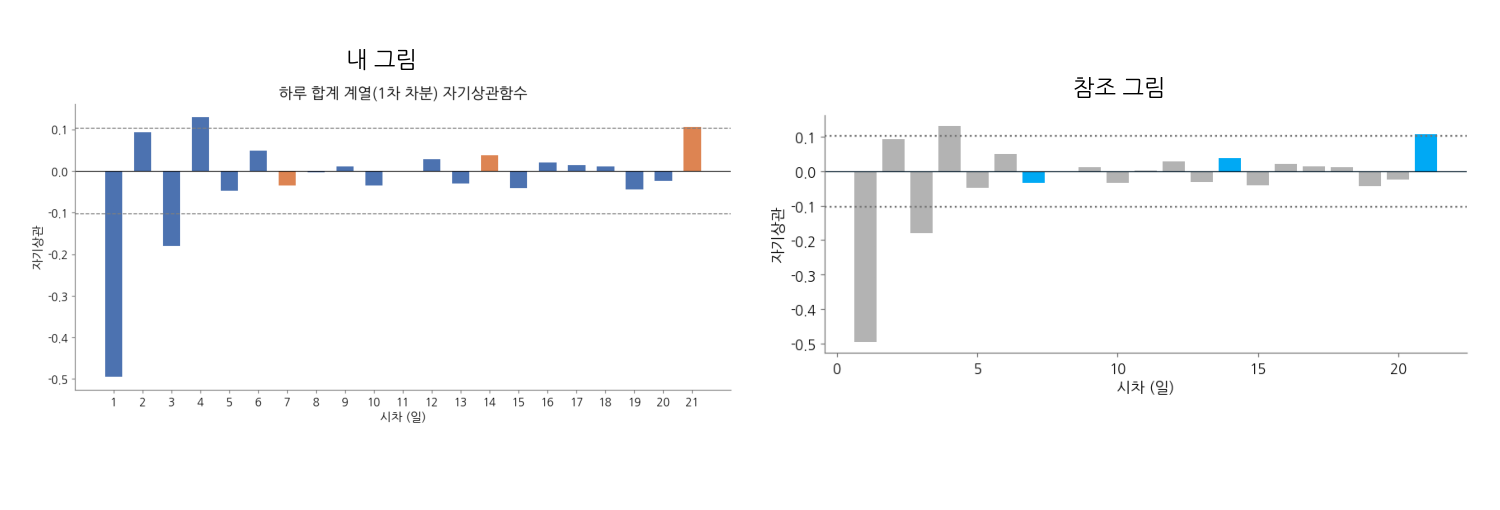

In [3]:
# 미션 1 — 프롬프트   # ai: prompt
# PROMPT 를 쓰고 → 도우미에 "위 PROMPT 대로 코드를 써 줘" → 「이 셀에 넣기」 → ▶
PROMPT = """
배차팀이 요청한 168시간을 하루 합계 365일 계열로 대신할 수 있을지 궁금한 상황이야. 일단 daily_c	: 일 수요 — 원본 시간 계열의 하루 합계 365일, 단위 대/일	
, auto_arima	: 차수를 자동으로 고르는 함수, df · df['count']	: 시간당 기록 표 전체와 원본 시간 계열, 단위 대, acf	: 시차별 자기상관을 한 번에 반환하는 함수	그대로 호출한다. 이 셀들은 만들어져 있어

아래를 출력해줘. 

1. 하루 합계 계열 1차 차분 횟수 d
2. 하루 합계 계열 AIC (단위 없는 점수, 소수점 아래 2자리)
3. 그래프 한 장 가로축은  시차 1일부터 21까지이고 세로축은 자기상관인 막대 그래프 그래프는 아래 내용을 지켜줘

* 대상 계열 : `daily_c` 에서 하루 전 값을 뺀 계열(1차 차분 1회)
* 막대 : 시차 1 부터 21 까지 21개
* 색 : 요일에 해당하는 시차 7 · 14 · 21 만 다른 색으로 강조합니다
* 가로 점선 : 경계선 ±1.96/√T 를 가로축 전체에 걸쳐 위아래 하나씩 2개
* 경계선 : 자기상관이 0 과 구별되는지 판단하는 기준선. T 는 그 계열의 자료 수
* 가로축 이름 : 「시차 (일)」 · 세로축 이름 : 「자기상관」


그리고 이번 탐색에서는 계정 차수를 고르지 않을거야. 또한 호출은 이웃한 차수만 이동하며 비교하는 단계적 탐색으로 해줘.
"""
# --- 여기부터 AI 코드 ---
import numpy as np
import matplotlib.pyplot as plt

# 한글 폰트가 이미 설정돼 있다면 아래 두 줄은 생략해도 됩니다
plt.rcParams['font.family'] = ['NanumGothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 1·2. 하루 합계 계열(daily_c)에 auto_arima를 적용해 d와 AIC를 구한다
# - 계절 차수는 탐색하지 않음 (seasonal=False)
# - 이웃 차수만 비교하는 단계적 탐색 (stepwise=True)
model = auto_arima(
    daily_c,
    seasonal=False,
    stepwise=True,
    information_criterion="aic",
)

d = model.order[1]
aic = model.aic()

print(f"1차 차분 횟수 d: {d}")
print(f"AIC: {aic:.2f}")

# 3. daily_c를 1차 차분한 계열의 자기상관함수(시차 1~21일)
diff_c = daily_c.diff().dropna()
T = len(diff_c)

acf_vals = acf(diff_c, nlags=21)
r = acf_vals[1:22]          # 시차 1~21만 사용 (시차 0 제외)
lags = np.arange(1, 22)

bound = 1.96 / np.sqrt(T)   # 경계선 ±1.96/√T

highlight_lags = {7, 14, 21}
colors = ['#DD8452' if lag in highlight_lags else '#4C72B0' for lag in lags]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(lags, r, color=colors, width=0.6)
ax.axhline(bound, color='gray', linestyle='--', linewidth=1)
ax.axhline(-bound, color='gray', linestyle='--', linewidth=1)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(lags)
ax.set_xlabel('시차 (일)')
ax.set_ylabel('자기상관')
ax.set_title('하루 합계 계열(1차 차분) 자기상관함수')
plt.tight_layout()
plt.show()

> **[문제] 미션 1 은 `auto_arima` 를 `seasonal=False` 로 호출합니다. 그 설정이 하는 일로 맞는 것은?**
>
> 1. 하루 합계 계열에서 계절성분을 먼저 빼고 남은 계열만 탐색에 넘긴다 — 계열 자체가 달라진다
> 2. 계절 주기를 선언하지 않아 탐색이 비계절 차수 p · d · q 만 고르게 한다 — 계열은 365일 그대로다
> 3. 계절 차수를 모두 0 으로 고정한 뒤 그 값을 결과에 함께 적는다 — 그래서 주기 값도 함께 출력된다

> **[문제] 미션 1 의 「참고」 행은 계절 차수를 (0, 0, 0, 0) 으로 출력합니다. 계절 차수 (P, D, Q, m) 의 가운데 값 D 와 마지막 값 m 이 뜻하는 것으로 맞는 것은?**
>
> 1. D 는 계절차분 횟수, m 은 계절 주기다 — 둘 다 0 이라 계절차분도 주기 선언도 없다
> 2. D 는 계절 차수의 개수, m 은 탐색이 적합한 후보의 개수다 — 둘 다 0 이라 적합이 없었다
> 3. D 는 1차 차분 횟수, m 은 계열의 길이다 — 비계절 차수 (p, d, q) 의 가운데 값 d 와 같은 뜻이다

## 2. 남은 차수 2개의 결정 — AIC 비교표

### 미션 2 [필수] — 남은 차수 2개를 AIC 로 결정하기 (함정 미션)

#### 할 일 — 미션 2 (25분)

1. 아래 「준비 셀」을 실행합니다. 이 셀은 고치지 않습니다.
2. 「PROMPT 셀」을 먼저 그대로 ▶ 해 전임 담당자 코드의 채점 결과(❌)를 봅니다. 고치는 것은 3번부터입니다. PROMPT 가 비어 있어도 이 채점은 출력됩니다.
3. 아래 고칠 것대로 PROMPT 를 쓰고, 미션 1 의 3번과 4번과 같은 순서로 코드를 받아 실행합니다.

**이 미션의 질문** — 후보 6조합의 AIC 를 한 표에 배치해 비교하려면 어디를 고쳐야 합니까?

**쓸 수 있는 것** — 「준비 셀」이 만들어 둔 이름입니다.

| 이름 | 무엇 | 다룸 |
|---|---|---|
| `y_train` | 학습 구간 보정 수요 1,848시간, 단위 대/시간 | 고정 |
| `D_LEVEL` · `D_SEASONAL` · `M` | 차분 조건 값 3개 — 1차 차분 0회 · 계절차분 1회 · 계절 주기 24 | 고정 |
| `P_GRID` | 비계절 자기회귀 차수 p 후보 3개 | 고정 |
| `Q_GRID` | 비계절 이동평균 차수 q 후보 2개 | 고정 |
| `FIT_OPTS` | 적합 옵션 문자열 | 그대로 적는다 |

후보 격자 p 0～2 · q 0～1 은 이론에서 좁힌 후보 넷을 모두 담는 범위입니다. 이론이 규칙대로 읽은 p = 3 은 격자에 넣지 않았습니다. 이 1,848시간에서 (3,0,0) · (3,0,1) 의 AIC 는 격자 안 1위보다 3 넘게 높습니다.

#### 고칠 것

전임 담당자의 코드는 오류 없이 실행되지만 값이 틀렸습니다. 고친 뒤 아래가 모두 출력되게 합니다. 굵은 이름은 글자 그대로 사용합니다.

1. **공식 차수 AIC** — 단위 없는 점수 · 소수점 아래 2자리 · AIC 가 가장 낮은 조합의 AIC
   - 고칠 곳 : 전임 코드가 차분 조건으로 적어 둔 값을 「준비 셀」이 출력한 고정값 3개와 하나씩 대조합니다. 어긋난 값이 코드 여러 곳에 적혀 있으면 모두 고칩니다
   - 차수를 출력하는 「공식 차수 = …」 행도 고친 차수로 적습니다
2. **1위와 2위의 AIC 차이** — 단위 없는 점수 · 소수점 아래 2자리 · AIC 가 가장 낮은 조합과 그다음 조합의 AIC 차이
   - 두 행의 차분 조건이 같아야 이 차이에 뜻이 있습니다
3. **그래프 한 장** — 가로축은 AIC, 세로축은 차수 라벨 6개인 가로 막대 그래프
   - 막대 : 후보 6조합에 하나씩, 모두 6개
   - 가로축 이름 : 「AIC (낮을수록 좋음)」 · 세로축 이름 : 「차수 (비계절)(계절)」
   - 세로 눈금 : 조합마다 차수 라벨 하나 — 「공식 차수」 행과 같은 모양으로, 고친 값으로 적습니다
   - 채점 대상은 아니지만 이렇게 두면 읽기 좋습니다 : AIC 가 낮은 것이 위로 오게 정렬 · 가장 낮은 막대 하나만 다른 색
   - 가로축 범위 25,000 부터 28,000 까지

**출력 형식** — 값 2개를 「이름 = 값」 형태로 서로 다른 행에 한 행씩 `print` 합니다. 그래프는 한 장입니다.

**통과 기준** — 굵은 이름 2개가 각각 자기 행에 적혀 있고 그 값이 기준 범위에 들며, 가로 막대 6개와 가로축·세로축 이름을 갖추면 통과입니다. 「공식 차수」 행과 세로 눈금의 차수 표기도 고친 차수여야 합니다. 적합만 고치고 출력 문자열을 그대로 두면 AIC 가 맞아도 통과하지 못합니다.

**읽는 법** — 고친 표를 AIC 순으로 정렬해 1위와 2위를 봅니다. 이론이 정한 기준대로 두 AIC 의 차이가 2 이하이면 두 후보를 구별할 수 없다고 보고, 항이 적은 쪽을 공식 차수로 고릅니다.

이론의 336시간과는 자료 길이가 달라 AIC 값 자체가 다르므로, 비교는 이 표 안에서만 합니다.

#### 프롬프트에 넣을 것(힌트)

- **고칠 곳** — 대조에서 어긋난 값이 어느 코드 행에 있고 무엇으로 바꿀지 한 구로 적습니다. 같은 값이 차수를 출력하는 `print` 와 막대 라벨 문자열에도 적혀 있으면 그곳도 함께 바꾸라고 적습니다.
- **손대지 않을 범위** — `y_train` 과 후보 2개(`P_GRID` · `Q_GRID`)는 다시 만들지 말고, 이미 그려진 가로 막대도 같은 형태로 유지하라고 적습니다.
- **출력** — 값 2개의 이름, 그리고 소수점 아래 몇 자리까지 출력할지.
- **그래프** — 막대 6개 · 가로축과 세로축 이름.

**막히면** — AI 튜터에게 「차분 횟수가 다른 모형끼리 AIC 를 비교할 수 없는 이유가 무엇인가요」 처럼 질문하세요.

#### 틀린 곳 찾기

전임 담당자 코드를 그대로 실행하면 표 6행과 값 3행이 출력됩니다. 그중 **위 2행(공식 차수 · 공식 차수 AIC)** 을 아래 빈칸에 옮겨 적고, 틀렸다고 판단한 곳에 근거 한 문장을 함께 적으세요. 고친 뒤 그 2행이 어떻게 달라지는지가 답입니다.

> **전임 코드의 차수와 AIC:** ____

> **[예측] 「여기부터 AI 코드」 아래 코드는 실행되는데 값이 틀렸습니다. 틀린 곳은 어디일까요?**
>
> 1. `order` 튜플의 가운데 값이 1 이다 — 6조합 전부에 1차 차분을 한 번씩 적용하고 있다
> 2. `seasonal_order` 의 마지막 값이 24 다 — 시간당 수요에 다른 주기를 전달했다
> 3. 학습 구간이 「준비 셀」의 계열 하나다 — 조합마다 다른 구간을 써야 한다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

<details class="lms-extra"><summary>배경 — 첫날이 정한 차수 3개와 오늘 정할 차수 2개</summary>

<img src="https://otexts.com/fpp3/fpp_files/figure-html/traintest-1.png" width="640" height="64"/>
<p align="center"><em>▲ 계열을 학습 구간과 검증 구간으로 나누는 방식 — 파란 점이 모형이 계수를 추정하는 학습 구간이고, 주황 점이 오차를 측정하는 검증 구간이다. 오늘의 AIC 는 왼쪽에 해당하는 학습 구간 1,848시간에서만 계산한다 (출처: Hyndman &amp; Athanasopoulos, Forecasting: Principles and Practice 3rd ed., 5.8)</em></p>

SARIMA 가 사용하는 숫자는 비계절 p · d · q 3개와 계절 P · D · Q · m 4개, 모두 7개입니다. 그중 3개는 첫날의 검정과 계절성 강도에서 이미 결정되었습니다.

| 숫자 | 값 | 첫날의 근거 |
|---|---|---|
| 계절 주기 m | 24 | 첫날 1년 구간에서 측정한 계절성 강도는 시각 주기 24 가 0.572, 요일 주기 7 이 0.089 였다. 그래서 하루 주기 24 를 계절 주기로 골랐다 |
| 계절차분 횟수 D | 1 | 원본은 ADF −6.95 · KPSS 8.005 로 둘 다 기각이라 두 답의 방향이 반대였다. 그래서 남은 구조를 ACF 로 보고, 주기 24 가 남아 있어 24시간 계절차분을 골랐다 |
| 1차 차분 횟수 d | 0 | 24시간 계절차분 뒤 다시 검정하니 ADF −17.0 · KPSS 0.008 로 둘 다 정상 쪽이었다. 그래서 1차 차분은 더 하지 않았다 |

남은 4개 가운데 **오늘 AIC 로 비교하는 것은 비계절 p 와 q 2개입니다.** 계절 P 와 Q 는 6조합 모두 0 으로 둡니다. AIC 는 이론의 「5. 후보 선택 기준 AIC 와 `auto_arima`」에서 정의한 점수이고, 낮을수록 좋으며 **차분 조건이 다른 모형끼리는 비교할 수 없습니다.**

차분을 한 번 더 적용하면 그 계열이 관측될 그럴듯함, 곧 **우도**를 계산한 계열 자체가 달라지기 때문입니다. 아래 두 그림이 그 「달라진다」입니다.

<img src="https://otexts.com/fpp3/fpp_files/figure-html/usemployment2-1.png" width="640" height="352"/>
<p align="center"><em>▲ 미국 고용 계열에 12개월 계절차분만 한 번 적용한 계열(위)과 그 자기상관·부분자기상관(아래) — 첫날 실습에서 본 그림이다 (출처: Hyndman &amp; Athanasopoulos, Forecasting: Principles and Practice 3rd ed., 9.1)</em></p>

<img src="https://otexts.com/fpp3/fpp_files/figure-html/usemployment3-1.png" width="640" height="352"/>
<p align="center"><em>▲ 같은 계열에 계절차분과 1차 차분을 잇달아 적용한 계열 — 위 그림과 세로축 눈금도, 아래 자기상관 막대의 모양도 다르다. 두 그림은 서로 다른 계열이고, 각각에서 계산한 AIC 를 한 표에서 비교할 수 없다 (출처: 같은 책, 9.1)</em></p>

</details>

<img src="https://otexts.com/fpp3/fpp_files/figure-html/h02b-1.png" width="640" height="395"/>
<p align="center"><em>▲ 로그를 취한 뒤 계절차분한 계열(위)과 그 자기상관·부분자기상관(아래) — 왼쪽 자기상관은 시차 9 까지 천천히 줄고, 오른쪽 부분자기상관은 시차 1～3 이 경계선 밖이고 그 뒤 비계절 시차에서는 안쪽으로 들어간다. 그래서 비계절 자기회귀 차수 p 의 후보는 3 이다. 계절차분을 적용한 뒤에도 이런 단서가 남는다 (출처: 같은 책, 9.9)</em></p>

In [4]:
# 미션 2 · 준비 — 읽고 실행만 합니다. 이 셀이 미션 2 에 쓸 변수를 직접 만듭니다
if "df" not in globals() or "demand" not in df.columns:   # 이 미션만 따로 열어도 단독으로 실행됩니다
    URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
    raw = pd.read_csv(URL, encoding="cp1252", compression="zip")      # 8,760행 x 14열
    #  받아지지 않으면: UCI 페이지에서 zip 을 내려받아 Colab 좌측 파일 패널에 올린 뒤
    #  URL 대신 "seoul+bike+sharing+demand.zip" 을 넣으세요
    raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",   # 위치 기반 리네임
                   "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
    raw["datetime"] = (pd.to_datetime(raw["date"], format="%d/%m/%Y")   # 01/12/2017 = 2017년 12월 1일
                       + pd.to_timedelta(raw["hour"], unit="h"))
    df = raw.sort_values("datetime").set_index("datetime")
    df.index.freq = "h"                   # 등간격 1시간 — 시차 24 가 "24시간 전" 이라는 뜻이 된다
    _s = df["count"].astype(float).mask(df["functioning"].eq("No"))   # 휴무는 0 이 아니라 관측 없음
    _y = _s.fillna(_s.shift(24 * 7))      # 1주일 전 같은 시각 값으로 채운다 (요일 효과를 지키려고)
    df["demand"] = _y.fillna(_y.shift(-24 * 7))   # 1주일 전도 휴무인 시각만 1주일 뒤 값으로
    df["is_imputed"] = df["functioning"].eq("No")

FIT_START, TRAIN_END = "2018-09-01 00:00", "2018-11-16 23:00"
y_train = df["demand"].loc[FIT_START:TRAIN_END]   # 쓸 변수 — 학습 구간의 보정 수요 (대/시간)

D_LEVEL, D_SEASONAL, M = 0, 1, 24         # 차분 조건 — 첫날의 검정과 계절성 강도가 정한 값 3개
P_GRID, Q_GRID = [0, 1, 2], [0, 1]        # 비계절 자기회귀·이동평균 후보
FIT_OPTS = "trend=None, enforce_stationarity=True, enforce_invertibility=True"

print(f"학습 구간 {FIT_START} ~ {TRAIN_END}   {len(y_train):,}시간   "
      f"채운 시각 {int(df['is_imputed'].loc[FIT_START:TRAIN_END].sum())}시간")
print(f"학습 평균 {y_train.mean():,.1f} 대/시간   결측 {int(y_train.isna().sum())}건")
print(f"차분 조건 고정 — 1차 차분 횟수 d = {D_LEVEL} · 계절차분 D = {D_SEASONAL} · 계절 주기 m = {M}")
print(f"계절 차수 고정 — (0, {D_SEASONAL}, 0, {M})   오늘 비교하는 것은 p 와 q 뿐입니다")
print(f"후보 격자 — p {P_GRID} x q {Q_GRID}   조합 {len(P_GRID) * len(Q_GRID)}개")
print(f"적합 옵션 통일 — {FIT_OPTS}")
print("여섯 조합을 모두 적합하는 데 1분이 채 걸리지 않습니다.")
print("쓸 수 있는 이름 : y_train (학습 구간 보정 수요, 대/시간) · D_LEVEL · D_SEASONAL · M"
      " (차분 조건 값 3개) · P_GRID (비계절 p 후보) · Q_GRID (비계절 q 후보)"
      " · FIT_OPTS (적합 옵션 문자열)")

학습 구간 2018-09-01 00:00 ~ 2018-11-16 23:00   1,848시간   채운 시각 247시간
학습 평균 986.6 대/시간   결측 0건
차분 조건 고정 — 1차 차분 횟수 d = 0 · 계절차분 D = 1 · 계절 주기 m = 24
계절 차수 고정 — (0, 1, 0, 24)   오늘 비교하는 것은 p 와 q 뿐입니다
후보 격자 — p [0, 1, 2] x q [0, 1]   조합 6개
적합 옵션 통일 — trend=None, enforce_stationarity=True, enforce_invertibility=True
여섯 조합을 모두 적합하는 데 1분이 채 걸리지 않습니다.
쓸 수 있는 이름 : y_train (학습 구간 보정 수요, 대/시간) · D_LEVEL · D_SEASONAL · M (차분 조건 값 3개) · P_GRID (비계절 p 후보) · Q_GRID (비계절 q 후보) · FIT_OPTS (적합 옵션 문자열)


 p  q      AIC
 1  1 25209.34
 2  1 25211.16
 2  0 25223.65
 1  0 25327.20
 0  1 26294.07
 0  0 27820.29
공식 차수 = (1,0,1)(0,1,0,24)
공식 차수 AIC = 25,209.34
1위와 2위의 AIC 차이 = 1.83

──────────────────────────────────────────────────────
◼ 미션 2 채점 결과
✅ 공식 차수 AIC — 출력에서 25,209.3 를 찾았습니다
✅ 1위와 2위의 AIC 차이 — 출력에서 1.83 를 찾았습니다
✅ 그래프 — 기준대로 그렸습니다
✅ 차수 표기 — 「공식 차수」 행과 막대 라벨이 고친 차수를 적고 있습니다
──────────────────────────────────────────────────────


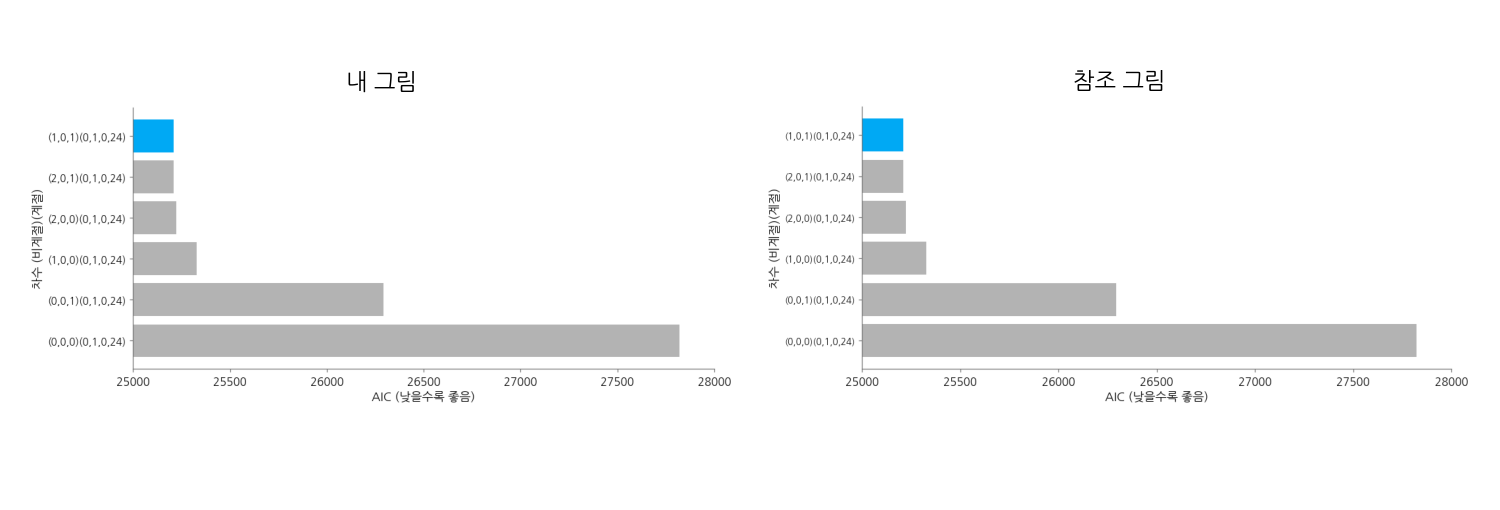

In [5]:
# 미션 2 — 프롬프트 (함정)   # ai: prompt
# 이 미션은 함정입니다 — 아래는 전임 담당자가 남긴 코드라 돌아가지만 답이 틀렸습니다.
# 어디를 어떻게 고칠지 PROMPT 에 쓰면 튜터가 AI 코드 표시선 아래를 다시 씁니다.
PROMPT = """
rows = []
for p, q in itertools.product(P_GRID, Q_GRID):
    _r = SARIMAX(y_train, order=(p, 1, q), seasonal_order=(0, D_SEASONAL, 0, M),
                 trend=None, enforce_stationarity=True,
                 enforce_invertibility=True).fit(disp=False)
    rows.append({"p": p, "q": q, "AIC": _r.aic})

grid = pd.DataFrame(rows).sort_values("AIC").reset_index(drop=True)
best = grid.iloc[0]
second = grid.iloc[1]
print(grid.round(2).to_string(index=False))
print(f"공식 차수 = ({int(best.p)},1,{int(best.q)})(0,{D_SEASONAL},0,{M})")
print(f"공식 차수 AIC = {best.AIC:,.2f}")
print(f"1위와 2위의 AIC 차이 = {second.AIC - best.AIC:,.2f}")

labels = [f"({int(r.p)},1,{int(r.q)})(0,{D_SEASONAL},0,{M})" for r in grid.itertuples()]
colors = [COL["하늘색"] if i == 0 else COL["연회색"] for i in range(len(grid))]
fig, ax = plt.subplots(figsize=(FIG_W, 4.4))
ax.barh(range(len(grid) - 1, -1, -1), grid["AIC"], color=colors)
ax.set_yticks(range(len(grid) - 1, -1, -1))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlim(25000, 28000)
ax.set_xlabel("AIC (낮을수록 좋음)")
ax.set_ylabel("차수 (비계절)(계절)")
plt.show()

해당 코드를 나래의 형식에 맞게 고쳐줘

미번에는 후보 6조합의 AIC를 한 표에 배치해 비교하려먼 어디를 고쳐야 하는지에 대해 답변할려고 해 일단 셀은 준비가 되어있어 [`y_train`	: 학습 구간 보정 수요 1,848시간, 단위 대/시간, D_LEVEL · D_SEASONAL · M	: 차분 조건 값 3개 — 1차 차분 0회 · 계절차분 1회 · 계절 주기 24, P_GRID	비계절 자기회귀 차수 p 후보 3개, Q_GRID	비계절 이동평균 차수 q 후보 2개, FIT_OPTS	적합 옵션 문자열] 

그리고 아래를 출력해줘

1. 공식 차수 AIC : 소수점 아래 2자리이고 AIC가 가장 낮은 조합의 AIC를 출력해줘
2. 1위와 2위의 AIC 차이 : 이것도 소수점 아래 2자리이고 AIC가 가장 낮은 조합과 그다음 조합의 차이로 계산해줘
3. 그래프 한장이고 형식은 아래와 같아.
- 막대 : 후보 6조합에 하나씩, 모두 6개
- 가로축 이름 : 「AIC (낮을수록 좋음)」 · 세로축 이름 : 「차수 (비계절)(계절)」
- 세로 눈금 : 조합마다 차수 라벨 하나 — 「공식 차수」 행과 같은 모양으로, 고친 값으로 적습니다
- 채점 대상은 아니지만 이렇게 두면 읽기 좋습니다 : AIC 가 낮은 것이 위로 오게 정렬 · 가장 낮은 막대 하나만 다른 색
- 가로축 범위 25,000 부터 28,000 까지
"""
# --- 여기부터 AI 코드 ---
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

rows = []
for p, q in itertools.product(P_GRID, Q_GRID):
    _r = SARIMAX(
        y_train,
        order=(p, D_LEVEL, q),
        seasonal_order=(0, D_SEASONAL, 0, M),
        trend=None,
        enforce_stationarity=True,
        enforce_invertibility=True,
    ).fit(disp=False)
    rows.append({"p": p, "q": q, "AIC": _r.aic})

grid = pd.DataFrame(rows).sort_values("AIC").reset_index(drop=True)
best = grid.iloc[0]
second = grid.iloc[1]

print(grid.round(2).to_string(index=False))
print(f"공식 차수 = ({int(best.p)},{D_LEVEL},{int(best.q)})(0,{D_SEASONAL},0,{M})")
print(f"공식 차수 AIC = {best.AIC:,.2f}")
print(f"1위와 2위의 AIC 차이 = {second.AIC - best.AIC:,.2f}")

# 그래프 — AIC 낮은 순으로 위에서부터, 최저 AIC 막대만 강조색
labels = [f"({int(r.p)},{D_LEVEL},{int(r.q)})(0,{D_SEASONAL},0,{M})" for r in grid.itertuples()]
colors = [COL["하늘색"] if i == 0 else COL["연회색"] for i in range(len(grid))]

fig, ax = plt.subplots(figsize=(FIG_W, 4.4))
ax.barh(range(len(grid) - 1, -1, -1), grid["AIC"], color=colors)
ax.set_yticks(range(len(grid) - 1, -1, -1))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlim(25000, 28000)
ax.set_xlabel("AIC (낮을수록 좋음)")
ax.set_ylabel("차수 (비계절)(계절)")
plt.tight_layout()
plt.show()

> **[문제] 미션 2 에서 고친 뒤의 코드는 `order` 튜플의 가운데 값을 6조합 모두 같은 값으로 둡니다. 그 값이 조합마다 달라지면 AIC 표에 무슨 일이 생기나요?**
>
> 1. 값의 크기만 조금 달라진다 — 순위는 그대로라 1위 차수는 바뀌지 않는다
> 2. 행마다 우도를 계산한 계열이 달라져 AIC 열이 서로 비교할 수 없는 점수가 된다 — 1위 차수까지 바뀔 수 있다
> 3. 차분을 더 한 조합은 관측 하나를 잃어 페널티 항(penalty term)이 커지므로 AIC 가 반드시 나빠진다

> **[문제] 미션 2 의 고친 표에서 1위는 (1,0,1)(0,1,0,24), 2위는 (2,0,1)(0,1,0,24) 입니다. 출력한 「1위와 2위의 AIC 차이」 는 1.83 입니다. 이 값을 읽는 방법으로 맞는 것은?**
>
> 1. 1위가 2위보다 낫다는 근거다 — AIC 는 낮을수록 좋으므로 차이의 크기와 무관하게 순위를 그대로 따른다
> 2. 두 모형의 예측이 시각마다 평균 1.83대 만큼 어긋난다는 뜻이다
> 3. 두 차수를 구별할 수 없다는 뜻이라 자기회귀 차수가 하나 적은 (1,0,1) 을 고른다

## 3. 오늘의 정리

배차팀장이 요청한 168시간을 채울 모형의 차수가 정해졌습니다. 아래 표는 오늘의 결과를 질문별로 나눈 것입니다.

| 오늘의 질문 | 우리가 얻은 답 |
|---|---|
| 하루 합계 계열로 대신할 수 있나 | 대신할 수 없습니다. 하루로 합치면 요일 차이가 1.22배로 흐려지고, 예측 1개가 하루 합계 하나라 시간대별 배차의 근거도 되지 않습니다 |
| 168시간을 채울 차수는 무엇인가 | 첫날이 정한 차분 조건을 6조합에 똑같이 적용한 뒤 AIC 로 골랐습니다. 공식 차수는 (1,0,1)(0,1,0,24) 이고 그 AIC 는 25,209.34 입니다 |
| 1위와 2위를 어떻게 갈랐나 | 차이가 1.83 이라 두 후보를 구별할 수 없어, 비계절 자기회귀 차수가 하나 적은 (1,0,1) 을 골랐습니다 |

한 문장으로 답하면 이렇습니다. **다음 주 168시간은 차수 (1,0,1)(0,1,0,24) 의 모형으로 채웁니다.**

<img src="https://otexts.com/fpp3/fpp_files/figure-html/usemployment7-1.png" width="640" height="320"/>
<p align="center"><em>▲ 계절 패턴을 이어 그리는 SARIMA 예측. 파란 선이 점 예측이고, 진한 영역이 80% · 옅은 영역이 95% 예측구간이다. 차수를 정한 모형은 이처럼 학습 구간 끝에서 그다음 시각들을 숫자로 채우고, 먼 시각일수록 예측구간이 길어진다 (출처: Hyndman &amp; Athanasopoulos, Forecasting: Principles and Practice 3rd ed., 9.9)</em></p>

AIC 표에서 1위와 2위의 차이는 1.83 이었습니다. 차분 조건을 한 곳만 어긋나게 적어도 순서가 반대가 되는 크기입니다. 그래서 차수와 AIC 를 문서에 남길 때 「1차 차분 0회 · 계절차분 1회 · 계절 주기 24 로 6조합 통일」이라는 조건을 함께 적습니다.

마무리로 완성본과 내 코드가 달랐던 부분 1곳과 거기서 배운 것 한 문장을 적어 팀 채널에 공유합니다.

<div style="background:#F2F2F2;color:#000000;padding:28px;border-radius:12px;border:1px solid #E6E6E6;margin-top:16px;border-left:4px solid #051C2C">
<h2 style="color:#000000;margin:0 0 8px 0">수고했습니다 — 차수 결정 완료</h2>
<div style="color:#656565">하루 합계 계열을 배제하고, 후보 6조합의 AIC 를 한 표에서 비교해 차수를 골랐습니다.</div>
</div>